In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Generating Synthetic Regression Dataset
np.random.seed(42)
X = np.sort(10* np.random.rand(100,1), axis=0)
# random.rand generates numbers between 0 and 1.
y = (2 * X.ravel() + 0.5 * X.ravel() ** 2 + 5 * np.sin(X.ravel()) + np.random.normal(0, 5, 100))
# X.ravel() converts it into a one-dimensional array


In [3]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)



In [13]:
# Train Models of Different Complexity
degrees = [1, 2, 4, 10]
results = []
for degree in degrees:

# Create Polynomial Features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create Linear Regression model
    model = LinearRegression()

    # Train model
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Calculate errors
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # R2 scores
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Store results
    results.append([degree, train_mse, test_mse, train_r2, test_r2])


# Display Results
results_df = pd.DataFrame(results, columns=["Degree", "Training MSE", "Testing MSE", "Training R2", "Testing R2"])
print(results_df)


   Degree  Training MSE  Testing MSE  Training R2  Testing R2
0       1     55.437254    53.520139     0.882576    0.879061
1       2     28.893999    31.611128     0.938799    0.928569
2       4     21.642440    18.082016     0.954158    0.959140
3      10     25.688497    25.335473     0.945588    0.942750


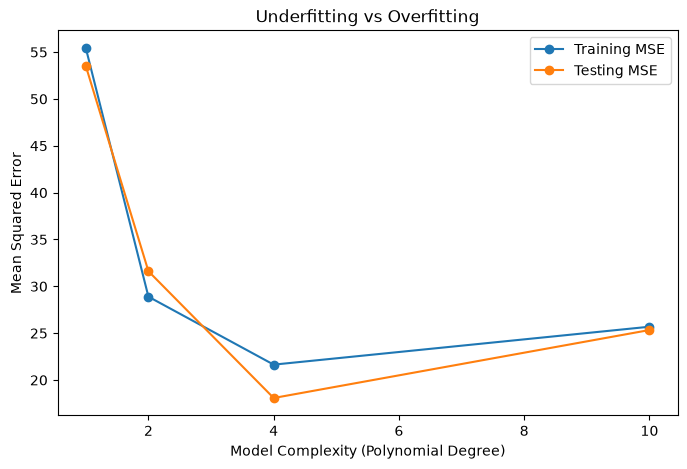

In [14]:
# Plot Training vs Testing Error
plt.figure(figsize=(8, 5))
plt.plot( results_df["Degree"], results_df["Training MSE"], marker='o', label="Training MSE")
plt.plot(results_df["Degree"], results_df["Testing MSE"], marker='o', label="Testing MSE")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared Error")
plt.title("Underfitting vs Overfitting")
plt.legend()
plt.show()


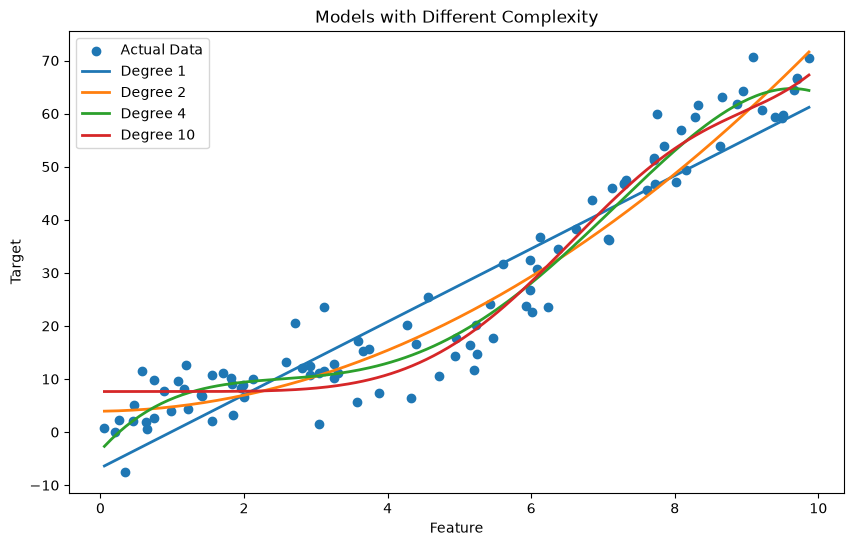

In [12]:
# Visualize Different Models
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="Actual Data")
X_curve = np.linspace( X.min(), X.max(), 200).reshape(-1, 1)
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    X_curve_poly = poly.transform(X_curve)

    y_curve = model.predict(X_curve_poly)
    plt.plot(X_curve, y_curve, linewidth=2, label=f"Degree {degree}")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Models with Different Complexity")
plt.legend()
plt.show()
